In [7]:
import cv2
import numpy as np
from pathlib import Path

In [1]:
import os

print(os.cpu_count())

10


In [8]:
from pathlib import Path

IMG_DIR = Path("mouse_dataset/images_perfect")

num_files = sum(1 for f in IMG_DIR.iterdir() if f.is_file())

print(f"Number of files: {num_files}")

Number of files: 1398


In [ ]:
from pathlib import Path

IMG_DIR = Path("mouse_dataset/images_mgs_crop_manual")

files = sorted(
    [f.name for f in IMG_DIR.glob("*.jpg")]
)
# 011742
target = "023149.jpg"

position = files.index(target) + 1

print(f"{target} is image #{position} out of {len(files)}")

023149.jpg is image #2000 out of 3011


In [2]:
def crop_inside_black_rectangle(image_path, output_path, margin=8):
    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 只找非常黑的像素
    mask = cv2.inRange(gray, 0, 45)

    # 找轮廓，用 RETR_LIST 而不是 RETR_EXTERNAL
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    candidates = []

    H, W = gray.shape

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        # 过滤太小的区域
        if w < 100 or h < 100:
            continue

        # 过滤整张图外边框
        if w > 0.95 * W or h > 0.95 * H:
            continue

        area = w * h
        candidates.append((x, y, w, h, area))

    if not candidates:
        raise ValueError("No black rectangle found")

    # 选面积最大的内部矩形
    x, y, w, h, _ = max(candidates, key=lambda b: b[4])

    # 去掉黑色边框本身，只保留框内内容
    crop = img[
        y + margin : y + h - margin,
        x + margin : x + w - margin
    ]

    cv2.imwrite(str(output_path), crop)

    return x, y, w, h

In [4]:
x,y,w,h=crop_inside_black_rectangle(
    "000008.jpg",
    "000008_crop.jpg"
)

## 剪裁+高斯模糊

In [5]:
import cv2
import numpy as np
from pathlib import Path


def create_muzzle_and_blur_ablation(
    boxed_image_path,
    original_image_path,
    muzzle_output,
    blur_output,
    margin=15,
    blur_kernel=301
):
    """
    输入:
        boxed_image_path:
            带黑框的图片，用来检测 muzzle box 坐标

        original_image_path:
            原始无黑框图片，用来生成最终图片

    输出:
        1. muzzle_output:
            黑框内部裁剪出的 muzzle-only 图片

        2. blur_output:
            原图中 muzzle 区域被高斯模糊后的图片，没有黑框
    """

    # =========================
    # 读取带黑框图片，用于检测坐标
    # =========================

    boxed_img = cv2.imread(str(boxed_image_path))

    if boxed_img is None:
        raise ValueError(f"Cannot read boxed image: {boxed_image_path}")

    gray = cv2.cvtColor(boxed_img, cv2.COLOR_BGR2GRAY)

    # =========================
    # 找黑框
    # =========================

    mask = cv2.inRange(gray, 0, 45)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    H, W = gray.shape
    candidates = []

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)

        if w < 100 or h < 100:
            continue

        # 排除整张图外边缘
        if w > 0.95 * W or h > 0.95 * H:
            continue

        area = w * h
        candidates.append((x, y, w, h, area))

    if len(candidates) == 0:
        raise ValueError(f"No black rectangle found: {boxed_image_path}")

    x, y, w, h, _ = max(candidates, key=lambda b: b[4])

    # =========================
    # 黑框内部区域，去掉边框线
    # =========================

    x1 = x + margin
    y1 = y + margin
    x2 = x + w - margin
    y2 = y + h - margin

    # 防止越界
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    if x2 <= x1 or y2 <= y1:
        raise ValueError("Invalid crop region after applying margin")

    # =========================
    # 读取原始无黑框图片
    # =========================

    original_img = cv2.imread(str(original_image_path))

    if original_img is None:
        raise ValueError(f"Cannot read original image: {original_image_path}")

    if original_img.shape[:2] != boxed_img.shape[:2]:
        raise ValueError(
            "Original image and boxed image must have the same width and height"
        )

    # =========================
    # 1. Muzzle Only
    # 从原始图片裁剪，而不是从带黑框图片裁剪
    # =========================

    muzzle_crop = original_img[y1:y2, x1:x2]

    cv2.imwrite(
        str(muzzle_output),
        muzzle_crop
    )

    # =========================
    # 2. Blur Ablation
    # 在原始图片上模糊 muzzle 区域，所以不会保留黑框
    # =========================

    blur_img = original_img.copy()

    roi = blur_img[y1:y2, x1:x2]

    if blur_kernel % 2 == 0:
        blur_kernel += 1

    blurred_roi = cv2.GaussianBlur(
        roi,
        (blur_kernel, blur_kernel),
        0
    )

    blur_img[y1:y2, x1:x2] = blurred_roi

    cv2.imwrite(
        str(blur_output),
        blur_img
    )

    return {
        "bbox": (x1, y1, x2, y2),
        "muzzle_size": muzzle_crop.shape,
        "blur_kernel": blur_kernel
    }

In [7]:


result = create_muzzle_and_blur_ablation(
    boxed_image_path="000008.jpg",
    original_image_path="000008.jpg",
    muzzle_output="000008_crop.jpg",
    blur_output="000008_blur.jpg",
    margin=15,
    blur_kernel=301
)

print(result)

{'bbox': (163, 15, 1003, 941), 'muzzle_size': (926, 840, 3), 'blur_kernel': 301}


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def make_result_table(df, save_path="results_table.png"):
    """
    Create a presentation-ready performance table.
    """

    # Select columns
    display = df[[
        "model",
        "input",
        "augmentation",
        "accuracy",
        "macro_f1",
        "roc_auc"
    ]].copy()

    display.columns = [
        "Model",
        "Input",
        "Aug.",
        "Accuracy",
        "Macro F1",
        "ROC AUC"
    ]

    # Round numbers
    for c in ["Accuracy", "Macro F1", "ROC AUC"]:
        display[c] = display[c].map(lambda x: f"{x:.3f}")

    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.axis("off")

    table = ax.table(
        cellText=display.values,
        colLabels=display.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8)

    # Header style
    for col in range(len(display.columns)):
        cell = table[(0, col)]
        cell.set_facecolor("#B22222")      # TU Berlin red
        cell.set_text_props(color="white", weight="bold")

    # Alternate row colors
    for row in range(1, len(display)+1):
        color = "#F7F7F7" if row % 2 == 0 else "white"
        for col in range(len(display.columns)):
            table[(row, col)].set_facecolor(color)

    # Highlight best Accuracy
    best = df["accuracy"].idxmax()
    table[(best+1, 3)].set_text_props(weight="bold", color="darkred")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def make_result_table(df, save_path="results_table.png"):
    """
    Create a presentation-ready performance table.
    """

    # Select columns
    display = df[[
        "run_name",
        "input",
        "augmentation",
        "accuracy",
        "macro_f1",
        "roc_auc"
    ]].copy()

    display.columns = [
        "Run Name",
        "Input",
        "Aug.",
        "Accuracy",
        "Macro F1",
        "ROC AUC"
    ]

    # Round numbers
    for c in ["Accuracy", "Macro F1", "ROC AUC"]:
        display[c] = display[c].map(lambda x: f"{x:.3f}")

    # Slightly wider figure because of the extra column
    fig, ax = plt.subplots(figsize=(15, 3.8))
    ax.axis("off")

    table = ax.table(
        cellText=display.values,
        colLabels=display.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    # Header style
    for col in range(len(display.columns)):
        cell = table[(0, col)]
        cell.set_facecolor("#B22222")      # TU Berlin red
        cell.set_text_props(color="white", weight="bold")

    # Alternate row colors
    for row in range(1, len(display)+1):
        color = "#F7F7F7" if row % 2 == 0 else "white"
        for col in range(len(display.columns)):
            table[(row, col)].set_facecolor(color)

    # Highlight best Accuracy
    best = df["accuracy"].idxmax()
    table[(best+1, 4)].set_text_props(weight="bold", color="darkred")
    #                ↑ Accuracy is now column index 4

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

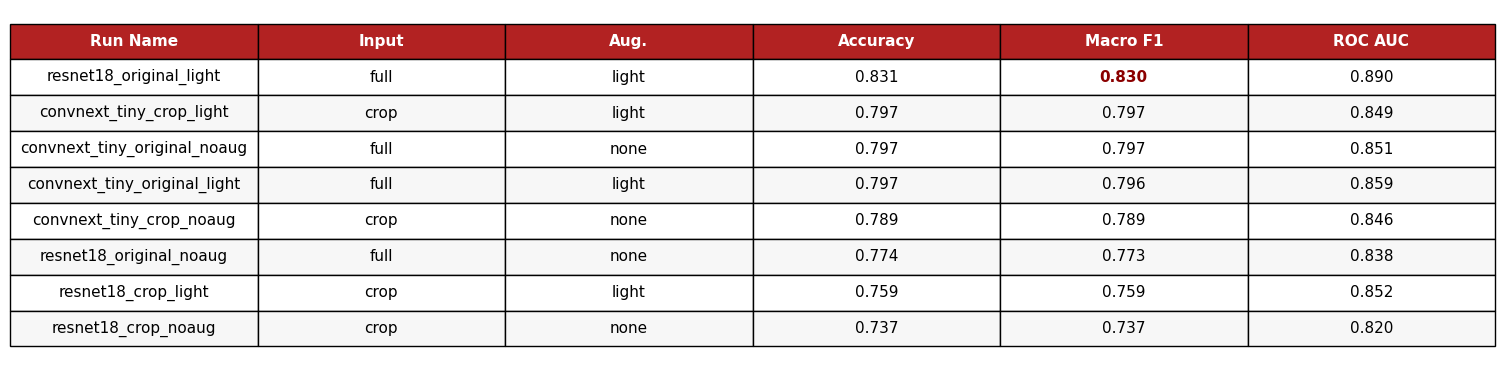

In [6]:
import pandas as pd

df = pd.DataFrame({
    "run_name": [
        "resnet18_original_light",
        "convnext_tiny_crop_light",
        "convnext_tiny_original_noaug",
        "convnext_tiny_original_light",
        "convnext_tiny_crop_noaug",
        "resnet18_original_noaug",
        "resnet18_crop_light",
        "resnet18_crop_noaug"
    ],
    "model": [
        "ResNet18",
        "ConvNeXt-Tiny",
        "ConvNeXt-Tiny",
        "ConvNeXt-Tiny",
        "ConvNeXt-Tiny",
        "ResNet18",
        "ResNet18",
        "ResNet18"
    ],
    "input": [
        "full","crop","full","full",
        "crop","full","crop","crop"
    ],
    "augmentation": [
        "light","light","none","light",
        "none","none","light","none"
    ],
    "accuracy":[0.831,0.797,0.797,0.797,0.789,0.774,0.759,0.737],
    "recall":[0.83,0.797,0.797,0.797,0.79,0.774,0.759,0.737],
    "macro_f1":[0.83,0.797,0.797,0.796,0.789,0.773,0.759,0.737],
    "roc_auc":[0.89,0.849,0.851,0.859,0.846,0.838,0.852,0.82]
})

make_result_table(df)

In [8]:
import matplotlib.pyplot as plt


def make_result_table(
    df,
    columns,
    headers=None,
    save_path="results_table.png",
    highlight_metric=None,
):
    """
    Make a presentation-ready table.

    Parameters
    ----------
    df : pandas.DataFrame

    columns : list
        Columns to display.

    headers : list
        Column names shown in PPT.
        If None, use columns.

    highlight_metric : str
        Column whose maximum value will be bold.
    """

    display = df[columns].copy()

    if headers is None:
        headers = columns

    display.columns = headers

    # format floats
    for col in display.columns:
        if display[col].dtype.kind == "f":
            display[col] = display[col].map(lambda x: f"{x:.3f}")

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axis("off")

    table = ax.table(
        cellText=display.values,
        colLabels=display.columns,
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    # header
    for c in range(len(display.columns)):
        cell = table[(0, c)]
        cell.set_facecolor("#B00020")
        cell.set_text_props(color="white", weight="bold")

    # alternate row colors
    for r in range(1, len(display) + 1):
        color = "#F5F5F5" if r % 2 == 0 else "white"
        for c in range(len(display.columns)):
            table[(r, c)].set_facecolor(color)

    # highlight best metric
    if highlight_metric is not None:
        best = df[highlight_metric].idxmax()
        metric_col = columns.index(highlight_metric)
        table[(best + 1, metric_col)].set_text_props(
            weight="bold",
            color="darkred"
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

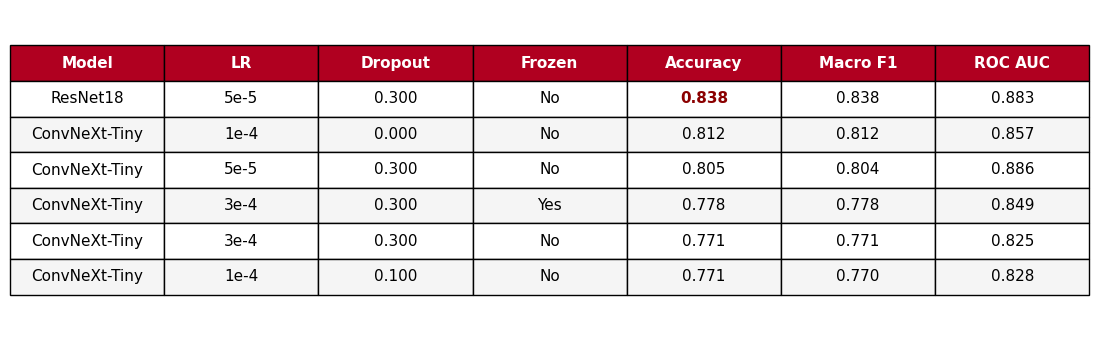

In [9]:
make_result_table(
    df,
    columns=[
        "model",
        "lr",
        "dropout",
        "frozen_backbone",
        "accuracy",
        "macro_f1",
        "roc_auc",
    ],
    headers=[
        "Model",
        "LR",
        "Dropout",
        "Frozen",
        "Accuracy",
        "Macro F1",
        "ROC AUC",
    ],
    highlight_metric="accuracy",
    save_path="hyperparameter_results.png",
)

In [16]:
import pandas as pd

ablation_part1 = pd.DataFrame({
    "Factor": [
        "Model",
        "Input",
        "Augmentation"
    ],
    "Options": [
        "ResNet18, ConvNeXt-Tiny",
        "crop, full",
        "none, light"
    ]
})

ablation_part2 = pd.DataFrame({
    "Tested Change": [
        "Learning rate 5e-5",
        "Learning rate 3e-4",
        "Dropout 0.0",
        "Dropout 0.1",
        "Frozen backbone",
        "ResNet18 full lr 5e-5"
    ],
    "Purpose": [
        "More stable fine-tuning",
        "More aggressive fine-tuning",
        "Test no regularization",
        "Lower regularization",
        "Feature extractor only",
        "Tune strongest full-image model"
    ]
})

In [17]:
import matplotlib.pyplot as plt


def make_ablation_table(
    df,
    title,
    save_path,
    figsize=(10, 3),
    header_color="#B00020"
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="left",
        colLoc="left",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1.2, 1.8)

    n_rows = len(df)
    n_cols = len(df.columns)

    # Header style
    for col in range(n_cols):
        cell = table[(0, col)]
        cell.set_facecolor(header_color)
        cell.set_text_props(color="white", weight="bold")
        cell.set_edgecolor("white")

    # Body style
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            cell = table[(row, col)]
            cell.set_facecolor("#F7F7F7" if row % 2 == 0 else "white")
            cell.set_edgecolor("#DDDDDD")

            if col == 0:
                cell.set_text_props(weight="bold")

    ax.set_title(title, fontsize=15, fontweight="bold", loc="left", pad=5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

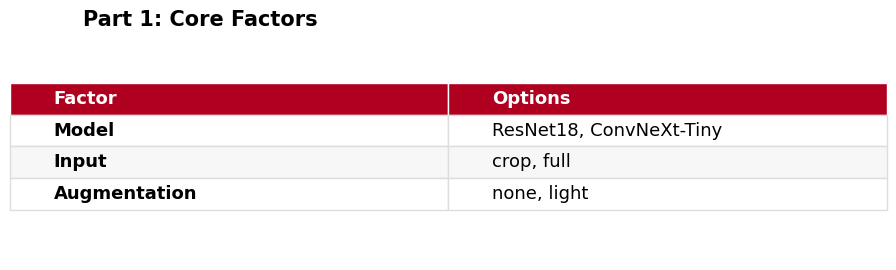

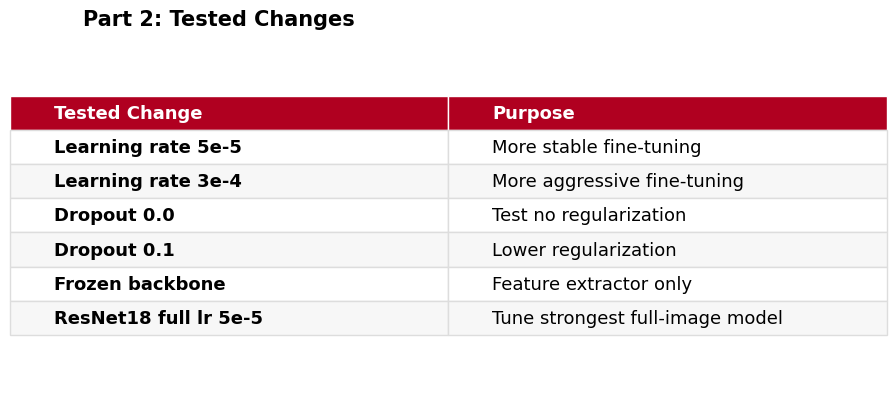

In [22]:
make_ablation_table(
    ablation_part1,
    title="Part 1: Core Factors",
    save_path="ablation_part1.png",
    figsize=(9, 2.8)
)

make_ablation_table(
    ablation_part2,
    title="Part 2: Tested Changes",
    save_path="ablation_part2.png",
    figsize=(9, 4.2)
)

In [23]:
import pandas as pd

df_compare = pd.DataFrame({
    "run_name": [
        "resnet18_original_light_lr5e5",
        "resnet18_original_light",
        "convnext_tiny_crop_light_dropout0",
        "convnext_tiny_crop_light_lr5e5",
        "convnext_tiny_crop_light",
        "convnext_tiny_original_noaug",
        "convnext_tiny_original_light",
        "convnext_tiny_crop_noaug",
        "convnext_tiny_crop_light_frozen",
        "resnet18_original_noaug",
        "convnext_tiny_crop_light_lr3e4",
        "convnext_tiny_crop_light_dropout1",
        "resnet18_crop_light",
        "resnet18_crop_noaug",
    ],
    "macro_f1": [
        0.838,
        0.830,
        0.812,
        0.804,
        0.797,
        0.797,
        0.796,
        0.789,
        0.778,
        0.773,
        0.771,
        0.770,
        0.759,
        0.737,
    ],
    "roc_auc": [
        0.883,
        0.890,
        0.857,
        0.886,
        0.849,
        0.851,
        0.859,
        0.846,
        0.849,
        0.838,
        0.825,
        0.828,
        0.852,
        0.820,
    ]
})

In [24]:
import matplotlib.pyplot as plt
import numpy as np


def plot_model_comparison(df, save_path="heldout_model_comparison_clear.png"):
    df = df.copy()

    # Sort by Macro-F1
    df = df.sort_values("macro_f1", ascending=True)

    y = np.arange(len(df))
    bar_height = 0.38

    fig, ax = plt.subplots(figsize=(12, 8))

    ax.barh(
        y - bar_height / 2,
        df["macro_f1"],
        height=bar_height,
        label="Macro-F1",
        color="#1F77B4"
    )

    ax.barh(
        y + bar_height / 2,
        df["roc_auc"],
        height=bar_height,
        label="ROC-AUC",
        color="#FF7F0E"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["run_name"], fontsize=10)

    ax.set_xlabel("Score", fontsize=12)
    ax.set_title("Held-Out Model Comparison", fontsize=16, fontweight="bold")

    ax.set_xlim(0.70, 0.92)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.legend(fontsize=11, loc="lower right")

    # Add value labels
    for i, (f1, auc) in enumerate(zip(df["macro_f1"], df["roc_auc"])):
        ax.text(f1 + 0.003, i - bar_height / 2, f"{f1:.3f}",
                va="center", fontsize=9)
        ax.text(auc + 0.003, i + bar_height / 2, f"{auc:.3f}",
                va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

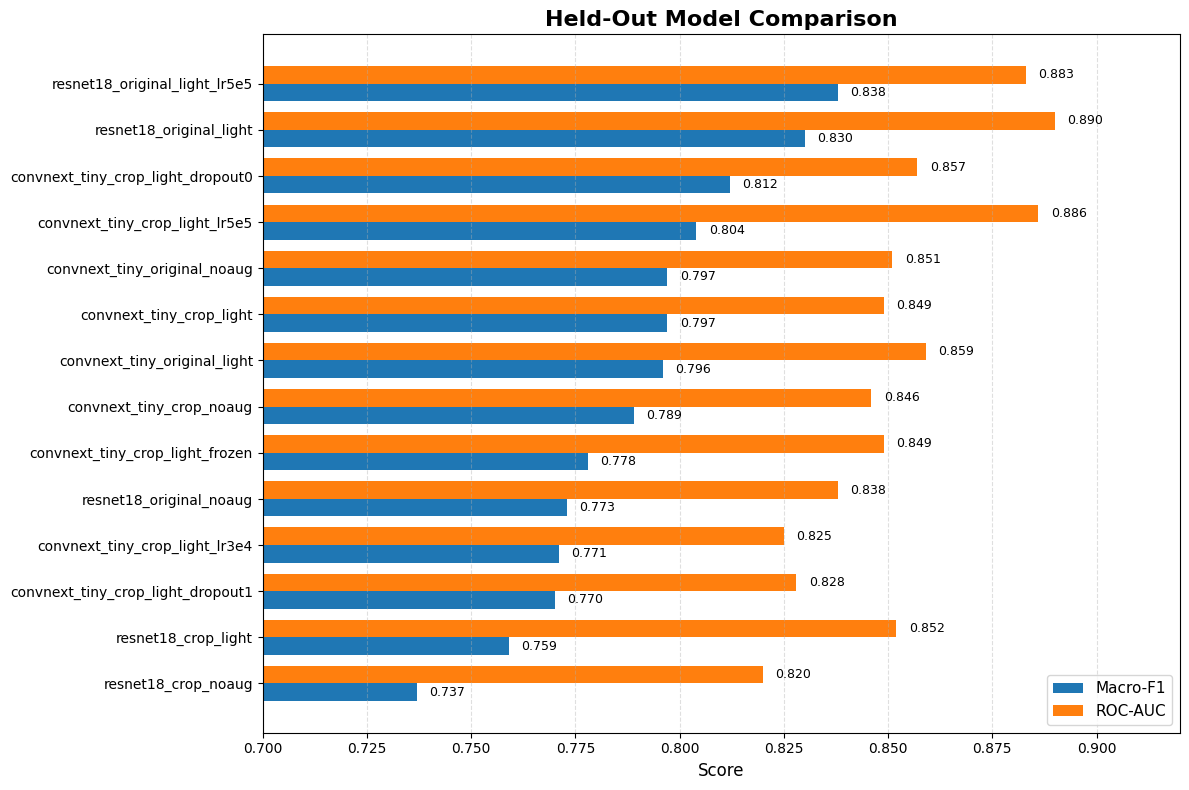

In [25]:
plot_model_comparison(df_compare)

In [26]:
import pandas as pd

df_hyper = pd.DataFrame({
    "run_name": [
        "resnet18_original_light_lr5e5",
        "convnext_tiny_crop_light_dropout0",
        "convnext_tiny_crop_light_lr5e5",
        "convnext_tiny_crop_light_frozen",
        "convnext_tiny_crop_light_lr3e4",
        "convnext_tiny_crop_light_dropout1",
    ],
    "macro_f1": [
        0.838,
        0.812,
        0.804,
        0.778,
        0.771,
        0.770,
    ],
    "roc_auc": [
        0.883,
        0.857,
        0.886,
        0.849,
        0.825,
        0.828,
    ]
})

In [27]:
import matplotlib.pyplot as plt
import numpy as np


def plot_hyperparameter_results(df,
                                save_path="hyperparameter_results.png"):

    df = df.copy()
    df = df.sort_values("macro_f1", ascending=True)

    y = np.arange(len(df))
    h = 0.36

    plt.figure(figsize=(11,5.2))

    plt.barh(
        y-h/2,
        df["macro_f1"],
        height=h,
        color="#4C78A8",
        label="Macro-F1"
    )

    plt.barh(
        y+h/2,
        df["roc_auc"],
        height=h,
        color="#F58518",
        label="ROC-AUC"
    )

    plt.yticks(y, df["run_name"], fontsize=11)

    plt.xlabel("Score", fontsize=12)
    plt.title(
        "Hyperparameter Ablation Study",
        fontsize=16,
        weight="bold"
    )

    plt.xlim(0.74,0.91)

    plt.grid(axis="x",
             linestyle="--",
             alpha=0.35)

    plt.legend(frameon=False,
               fontsize=11)

    # value labels
    for i,(f1,auc) in enumerate(zip(df["macro_f1"],
                                    df["roc_auc"])):

        plt.text(
            f1+0.002,
            i-h/2,
            f"{f1:.3f}",
            va="center",
            fontsize=9
        )

        plt.text(
            auc+0.002,
            i+h/2,
            f"{auc:.3f}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.savefig(save_path,
                dpi=300,
                bbox_inches="tight")
    plt.show()

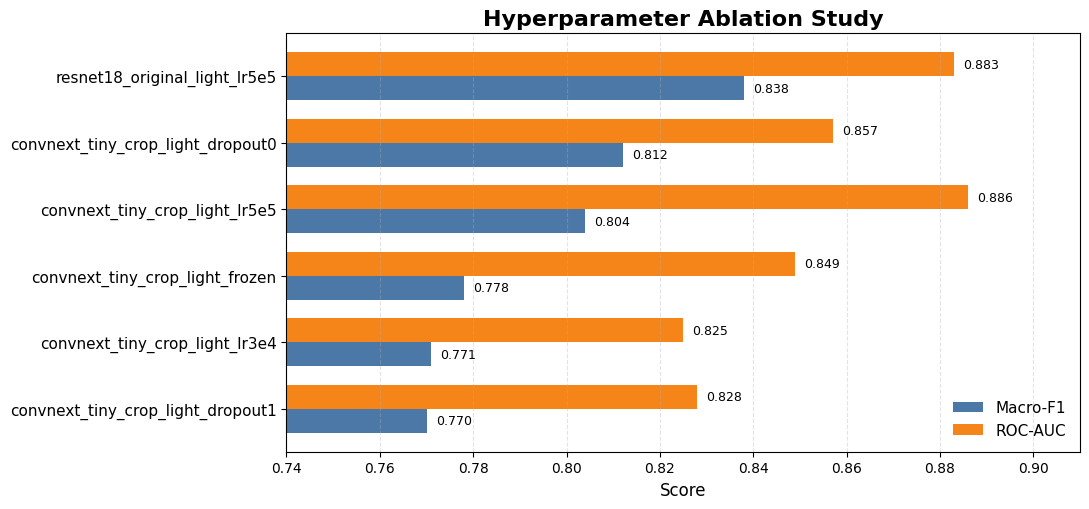

In [28]:
plot_hyperparameter_results(df_hyper)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt


summary_df = pd.DataFrame({
    "Setting": [
        "Overall",
        "Crop-only"
    ],
    "Best Model": [
        "ResNet18\n(full image, light aug, lr=5e-5)",
        "ConvNeXt-Tiny\n(crop, light aug, dropout=0.0)"
    ],
    "Accuracy": [0.838, 0.812],
    "Recall": [0.838, 0.812],
    "Macro-F1": [0.838, 0.812],
    "ROC-AUC": [0.883, 0.857]
})

In [38]:
def make_summary_table(df,
                       save_path="best_models_summary.png"):

    display = df.copy()

    # 保留三位小数
    for col in ["Accuracy", "Recall", "Macro-F1", "ROC-AUC"]:
        display[col] = display[col].map(lambda x: f"{x:.3f}")

    fig, ax = plt.subplots(figsize=(11, 2.8))
    ax.axis("off")

    table = ax.table(
        cellText=display.values,
        colLabels=display.columns,
        cellLoc="center",
        loc="center"
    )
    # Column widths
    column_widths = {
        0: 0.14,   # Setting
        1: 0.34,   # Best Model
        2: 0.13,   # Accuracy
        3: 0.13,   # Recall
        4: 0.13,   # Macro-F1
        5: 0.13    # ROC-AUC
    }

    for (row, col), cell in table.get_celld().items():
        if col in column_widths:
            cell.set_width(column_widths[col])

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.2)
    # Increase row height for data rows
    for row in [1, 2]:      # 第1、2行数据（header 是第0行）
        for col in range(len(display.columns)):
            cell = table[(row, col)]
            cell.set_height(0.22)   # 默认大约0.10，可以试0.16~0.20
            
    # Header
    for col in range(len(display.columns)):
        cell = table[(0, col)]
        cell.set_facecolor("#B00020")   # TU Berlin red
        cell.set_text_props(color="white", weight="bold")
        cell.set_edgecolor("white")

    # Body
    for row in range(1, len(display)+1):
        color = "#F7F7F7" if row % 2 == 0 else "white"

        for col in range(len(display.columns)):
            cell = table[(row, col)]
            cell.set_facecolor(color)
            cell.set_edgecolor("#DDDDDD")

    # Highlight Overall row
    for col in range(len(display.columns)):
        table[(1, col)].set_text_props(weight="bold")

    plt.title(
        "Best Model Summary",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()
    plt.savefig(save_path,
                dpi=300,
                bbox_inches="tight")
    plt.show()

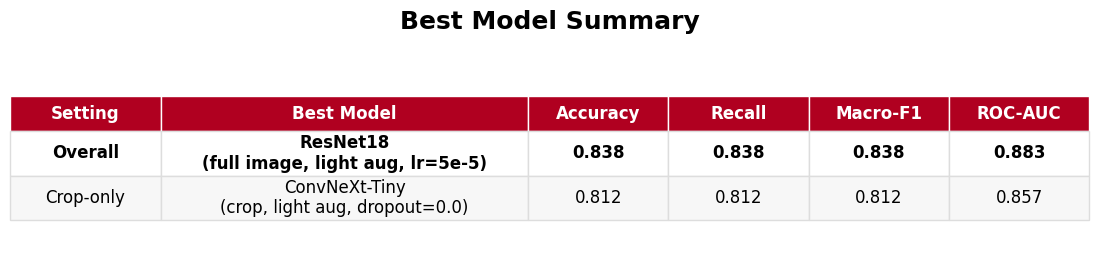

In [39]:
make_summary_table(summary_df)

In [1]:
import pandas as pd

df_ablation_base = pd.DataFrame({
    "run_name": [
        "resnet18_original_light",
        "convnext_tiny_crop_light",
        "convnext_tiny_original_noaug",
        "convnext_tiny_original_light",
        "convnext_tiny_crop_noaug",
        "resnet18_original_noaug",
        "resnet18_crop_light",
        "resnet18_crop_noaug",
    ],
    "macro_f1": [
        0.830,
        0.797,
        0.797,
        0.796,
        0.789,
        0.773,
        0.759,
        0.737,
    ],
    "roc_auc": [
        0.890,
        0.849,
        0.851,
        0.859,
        0.846,
        0.838,
        0.852,
        0.820,
    ]
})

In [2]:
import matplotlib.pyplot as plt
import numpy as np


def plot_base_ablation_results(df, save_path="base_ablation_results.png"):
    df = df.copy()
    df = df.sort_values("macro_f1", ascending=True)

    y = np.arange(len(df))
    h = 0.36

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.barh(
        y - h / 2,
        df["macro_f1"],
        height=h,
        label="Macro-F1",
        color="#4C78A8"
    )

    ax.barh(
        y + h / 2,
        df["roc_auc"],
        height=h,
        label="ROC-AUC",
        color="#F58518"
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["run_name"], fontsize=10)

    ax.set_xlabel("Score", fontsize=12)
    ax.set_title("Held-Out Model Comparison", fontsize=16, fontweight="bold")

    ax.set_xlim(0.70, 0.92)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.legend(frameon=False, fontsize=11, loc="lower right")

    for i, (f1, auc) in enumerate(zip(df["macro_f1"], df["roc_auc"])):
        ax.text(f1 + 0.003, i - h / 2, f"{f1:.3f}", va="center", fontsize=9)
        ax.text(auc + 0.003, i + h / 2, f"{auc:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

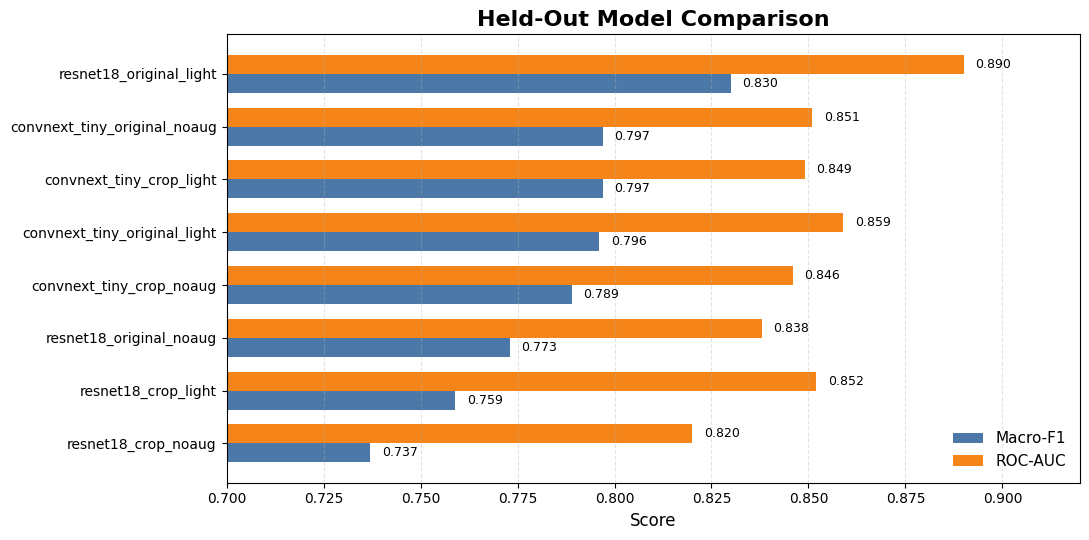

In [3]:
plot_base_ablation_results(df_ablation_base)